In [ ]:
# Vectorize Multiple PCI Matrices Into One Data Frame
# David H. Nguyen, PhD | Tissue Spatial Geometrics Lab

### Description ###
# This script turns matrices from the Position & Composition Index (PCI) into
#   vectors that are columns of a dataframe. 
# This script was written to work with CSV files outputed by the software 
#   GlycoAssessor v0.3.0. The CSV files should be formatted exactly as 
#   shown in the image below. Column headers must be spelled exactly as shown.

### Insructions ###
# Paste the file path to the working directory that contains the csv files.
#   Paste this in the section called: 
#   "Step 1. Set working directory containing input CSV files"
# The output is a csv filed called "vectorized-PCI-matrices.csv"

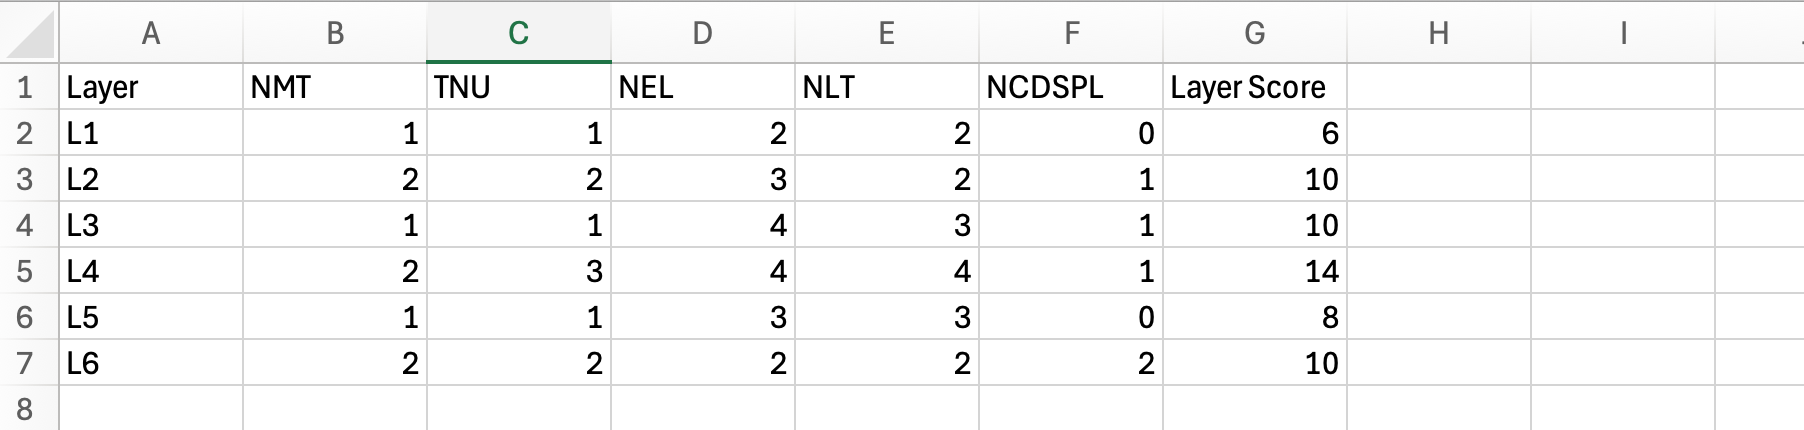

In [ ]:
# Load the dependencies
import os
import glob
import pandas as pd
import numpy as np

In [ ]:
# --------------------------------------------------
# Step 1. Set working directory containing input CSV files
# --------------------------------------------------
folder_path = 'pasteFilePathHere'

# Change working directory
os.chdir(folder_path)

# Print current directory
print("Current working directory:")
print(os.getcwd())

# Print folder contents
print("\nFolder contents:")

for item in os.listdir(folder_path):
    print(item)

In [ ]:
# --------------------------------------------------
# Step 2
#
# Find all CSV files
# --------------------------------------------------
csv_files = glob.glob("*.csv")

# Dictionary to hold vectorized columns
vector_dict = {}

# Dictionary to hold loaded dataframes
dataframes = {}

# List to hold row names
row_names = []

# --------------------------------------------------
# First pass:
# Find maximum number of rows
# --------------------------------------------------
max_rows = 0

for file in csv_files:

    # Skip previously generated output files
    if "_vectorized-PCI-matrices" in file:
        continue

    print(f"Scanning: {file}")

    # Load CSV
    df = pd.read_csv(file)

    # Ignore first column ("Layer")
    df = df.iloc[:, 1:]

    # Store dataframe
    dataframes[file] = df

    # Update maximum row count
    if df.shape[0] > max_rows:
        max_rows = df.shape[0]

print(f"\nMaximum row count found: {max_rows}")

# --------------------------------------------------
# Create row-name labels
#
# Example:
# L1-NMT
# L2-NMT
# ...
# L1-TNU
# L2-TNU
# ...
# --------------------------------------------------
first_df = next(iter(dataframes.values()))

for column in first_df.columns:

    for i in range(1, max_rows + 1):

        row_names.append(f"L{i}-{column}")

# --------------------------------------------------
# Second pass:
# Pad rows BEFORE stacking
# Then vectorize columns vertically
# --------------------------------------------------
for file, df in dataframes.items():

    print(f"Processing: {file}")

    current_rows = df.shape[0]

    # --------------------------------------------------
    # Pad dataframe with zero rows
    # BEFORE stacking
    # --------------------------------------------------
    if current_rows < max_rows:

        rows_to_add = max_rows - current_rows

        zero_rows = pd.DataFrame(
            0,
            index=range(rows_to_add),
            columns=df.columns
        )

        df = pd.concat([df, zero_rows], ignore_index=True)

    # --------------------------------------------------
    # Stack columns vertically
    # --------------------------------------------------
    vector = []

    for column in df.columns:

        vector.extend(df[column].tolist())

    # Store vector using filename
    base_name = os.path.splitext(file)[0]

    vector_dict[base_name] = vector

# --------------------------------------------------
# Create combined dataframe
# --------------------------------------------------
combined_df = pd.DataFrame(vector_dict)

# --------------------------------------------------
# Insert row-name column as first column
# Header is blank
# --------------------------------------------------
combined_df.insert(0, "", row_names)

# --------------------------------------------------
# Save output
# --------------------------------------------------
output_file = "vectorized-PCI-matrices.csv"

combined_df.to_csv(output_file, index=False)

print(f"\nSaved combined matrix to:\n{output_file}")

print("\nFinal shape:")
print(combined_df.shape)